<a href="https://colab.research.google.com/github/Brycekoh/adversarial_examples/blob/main/AdversarialAttacksResearchFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Attack

Using device: cuda
Done.
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 152MB/s]


ResNet50 loaded.


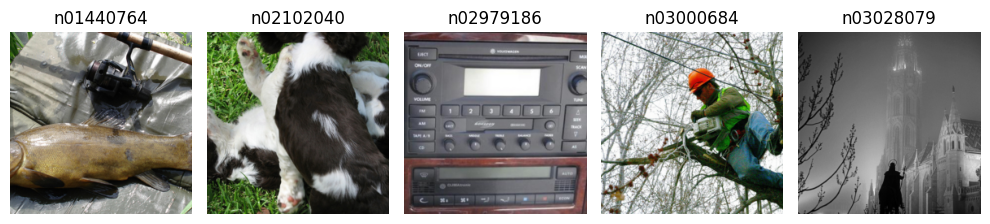

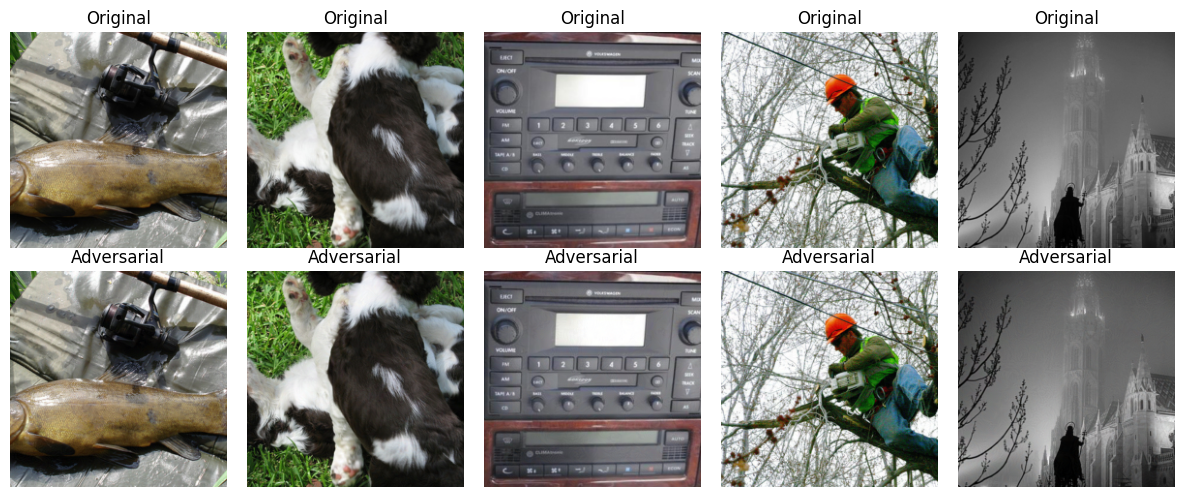


RESULTS:
----------------------------------------------------------------------
Image 0 (true: n01440764)
  ORIGINAL: tench                     | class code: 0 | 99.5%
  ATTACKED: reel                      | class code: 758 | 100.0%
----------------------------------------------------------------------
Image 1 (true: n02102040)
  ORIGINAL: English Springer Spaniel  | class code: 217 | 81.8%
  ATTACKED: Shih Tzu                  | class code: 155 | 100.0%
----------------------------------------------------------------------
Image 2 (true: n02979186)
  ORIGINAL: tape player               | class code: 848 | 60.2%
  ATTACKED: space bar                 | class code: 810 | 95.2%
----------------------------------------------------------------------
Image 3 (true: n03000684)
  ORIGINAL: chainsaw                  | class code: 491 | 61.1%
  ATTACKED: lorikeet                  | class code: 90 | 100.0%
----------------------------------------------------------------------
Image 4 (true: n030

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import json
import os
import urllib.request
import tarfile

# ─────────────────────────────────────────────
# DEVICE
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
print(f"Using device: {device}")

# ─────────────────────────────────────────────
# 1. DOWNLOAD IMAGENETTE
# ─────────────────────────────────────────────
url = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2.tgz"

if not os.path.exists('./imagenette2'):
    print("Downloading ImageNette...")
    urllib.request.urlretrieve(url, "imagenette2.tgz")
    with tarfile.open("imagenette2.tgz") as f:
        f.extractall(".", filter="data")
    os.remove("imagenette2.tgz")
    print("Done.")
else:
    print("ImageNette already exists, skipping download.")

# ─────────────────────────────────────────────
# 2. DATA
# ─────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_set = ImageFolder('./imagenette2/train', transform=transform)
test_set  = ImageFolder('./imagenette2/val', transform=transform)

print("Classes:", train_set.classes)

# ─────────────────────────────────────────────
# 3. LOAD IMAGENET LABELS
# ─────────────────────────────────────────────
url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
with urllib.request.urlopen(url) as r:
    imagenet_labels = json.loads(r.read())

# ─────────────────────────────────────────────
# 4. MODEL
# ─────────────────────────────────────────────
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(device)
model.eval()
print("ResNet50 loaded.")

# ─────────────────────────────────────────────
# 5. SELECT 1 IMAGE PER CLASS (5 CLASSES)
# ─────────────────────────────────────────────
def get_one_image_per_class(dataset, num_classes=5):
    class_indices = {i: None for i in range(num_classes)}

    for idx, (img, label) in enumerate(dataset):
        if label < num_classes and class_indices[label] is None:
            class_indices[label] = idx

        if all(v is not None for v in class_indices.values()):
            break

    images, labels = [], []

    for c in range(num_classes):
        img, label = dataset[class_indices[c]]
        images.append(img)
        labels.append(label)

    return torch.stack(images), torch.tensor(labels)

images, labels = get_one_image_per_class(test_set, num_classes=5)

images = images.to(device)
labels = labels.to(device)

# ─────────────────────────────────────────────
# DENORMALIZATION
# ─────────────────────────────────────────────
def denorm(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
    return (tensor * std + mean).clamp(0, 1)

# ─────────────────────────────────────────────
# VISUALISE ORIGINAL
# ─────────────────────────────────────────────
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(denorm(images[i]).cpu().permute(1, 2, 0))
    plt.title(train_set.classes[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 6. I-FGSM ATTACK
# ─────────────────────────────────────────────
def i_fgsm(model, images, labels, eps=0.03, alpha=0.005, iters=40):

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    # ONLY 5 classes mapping
    imagenette_to_imagenet = [0, 217, 482, 491, 497]

    mapped_labels = torch.tensor(
        [imagenette_to_imagenet[l] for l in labels.cpu()],
        device=device
    )

    loss_fn = nn.CrossEntropyLoss()
    adv_images = images.clone().detach().requires_grad_(True)

    for _ in range(iters):
        outputs = model(adv_images)
        loss = loss_fn(outputs, mapped_labels)

        model.zero_grad()
        loss.backward()

        adv_images = adv_images + alpha * adv_images.grad.sign()

        eta = torch.clamp(adv_images - images, min=-eps, max=eps)
        adv_images = torch.clamp(images + eta, min=-3.0, max=3.0)

        adv_images = adv_images.detach().requires_grad_(True)

    return adv_images.detach(), images.detach()

# ─────────────────────────────────────────────
# RUN ATTACK
# ─────────────────────────────────────────────
adv_batch, orig_batch = i_fgsm(model, images, labels)

# ─────────────────────────────────────────────
# VISUALISE RESULTS
# ─────────────────────────────────────────────
plt.figure(figsize=(12, 5))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(denorm(orig_batch[i]).cpu().permute(1, 2, 0))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(denorm(adv_batch[i]).cpu().permute(1, 2, 0))
    plt.title("Adversarial")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 7. PREDICTIONS
# ─────────────────────────────────────────────
with torch.no_grad():
    orig_out = model(orig_batch)
    adv_out  = model(adv_batch)

    orig_prob, orig_idx = torch.softmax(orig_out, dim=1).max(dim=1)
    adv_prob, adv_idx   = torch.softmax(adv_out, dim=1).max(dim=1)

# ─────────────────────────────────────────────
# 8. RESULTS
# ─────────────────────────────────────────────
print("\nRESULTS:")
print("-" * 70)

for i in range(5):
    true_class = train_set.classes[labels[i].item()]

    orig_class_name = imagenet_labels[orig_idx[i].item()]
    adv_class_name  = imagenet_labels[adv_idx[i].item()]

    orig_class_code = orig_idx[i].item()
    adv_class_code  = adv_idx[i].item()

    print(f"Image {i} (true: {true_class})")

    print(f"  ORIGINAL: {orig_class_name:25s} | class code: {orig_class_code} | {orig_prob[i].item()*100:.1f}%")

    print(f"  ATTACKED: {adv_class_name:25s} | class code: {adv_class_code} | {adv_prob[i].item()*100:.1f}%")

    print("-" * 70)

Using device: cuda
Epoch 1: Loss = 141.7128
Epoch 2: Loss = 41.5993
Epoch 3: Loss = 27.5306


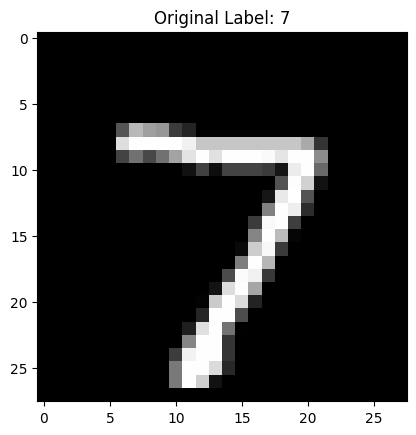

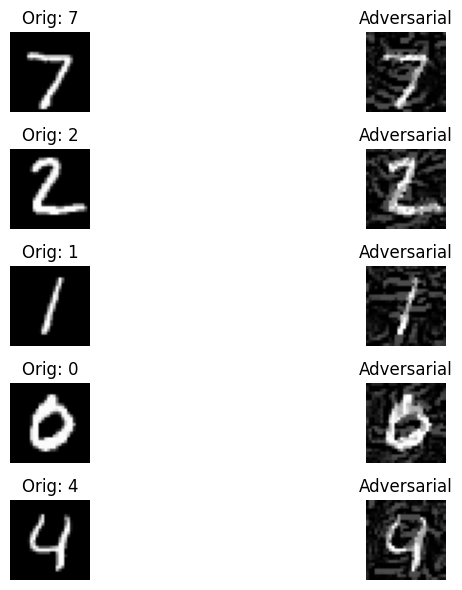


RESULTS:
----------------------------------------
Image 0
  ORIGINAL: 7 (true: 7)  — 100.0% confident
  ATTACKED: 3  — 100.0% confident
----------------------------------------
Image 1
  ORIGINAL: 2 (true: 2)  — 100.0% confident
  ATTACKED: 1  — 81.4% confident
----------------------------------------
Image 2
  ORIGINAL: 1 (true: 1)  — 100.0% confident
  ATTACKED: 7  — 100.0% confident
----------------------------------------
Image 3
  ORIGINAL: 0 (true: 0)  — 100.0% confident
  ATTACKED: 6  — 99.8% confident
----------------------------------------
Image 4
  ORIGINAL: 4 (true: 4)  — 100.0% confident
  ATTACKED: 9  — 99.9% confident
----------------------------------------


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 1. DEVICE
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ─────────────────────────────────────────────
# 2. DATA
# ─────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor()
])

train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)

# ─────────────────────────────────────────────
# 3. SIMPLE CNN MODEL (MNIST)
# ─────────────────────────────────────────────
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MNIST_CNN().to(device)

# ─────────────────────────────────────────────
# 4. TRAIN MODEL
# ─────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

def train(model, loader, epochs=3):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = loss_fn(output, target)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}: Loss = {total_loss:.4f}")

train(model, train_loader)

# ─────────────────────────────────────────────
# 5. LOAD TEST BATCH
# ─────────────────────────────────────────────
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

# Show original sample
plt.imshow(images[0].cpu().squeeze(), cmap="gray")
plt.title(f"Original Label: {labels[0].item()}")
plt.show()

# ─────────────────────────────────────────────
# 6. I-FGSM ATTACK
# ─────────────────────────────────────────────
def i_fgsm(model, images, labels, eps=0.3, alpha=0.01, iters=20):

    images = images.clone().detach()
    labels = labels.to(device)

    adv_images = images.clone().detach().requires_grad_(True)

    for _ in range(iters):
        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        model.zero_grad()
        loss.backward()

        adv_images = adv_images + alpha * adv_images.grad.sign()

        eta = torch.clamp(adv_images - images, min=-eps, max=eps)
        adv_images = torch.clamp(images + eta, 0, 1).detach_()
        adv_images.requires_grad = True

    return adv_images, images

adv_batch, orig_batch = i_fgsm(model, images[:5], labels[:5], eps=0.3, alpha=0.01, iters=40)

# ─────────────────────────────────────────────
# 7. VISUALIZATION
# ─────────────────────────────────────────────
plt.figure(figsize=(10, 6))

for i in range(5):
    # original
    plt.subplot(5, 2, i*2 + 1)
    plt.imshow(orig_batch[i].cpu().squeeze(), cmap="gray")
    plt.title(f"Orig: {labels[i].item()}")
    plt.axis("off")

    # adversarial
    plt.subplot(5, 2, i*2 + 2)
    plt.imshow(adv_batch[i].detach().cpu().squeeze(), cmap="gray")
    plt.title("Adversarial")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 8. PREDICTIONS
# ─────────────────────────────────────────────
model.eval()

with torch.no_grad():
    orig_out = model(orig_batch.to(device))
    adv_out  = model(adv_batch.to(device))

    orig_probs = torch.softmax(orig_out, dim=1)
    adv_probs  = torch.softmax(adv_out, dim=1)

    orig_conf, orig_pred = orig_probs.max(dim=1)
    adv_conf,  adv_pred  = adv_probs.max(dim=1)

# ─────────────────────────────────────────────
# 9. RESULTS
# ─────────────────────────────────────────────
print("\nRESULTS:")
print("-" * 40)

for i in range(5):
    print(f"Image {i}")
    print(f"  ORIGINAL: {orig_pred[i].item()} (true: {labels[i].item()})  — {orig_conf[i].item()*100:.1f}% confident")
    print(f"  ATTACKED: {adv_pred[i].item()}  — {adv_conf[i].item()*100:.1f}% confident")
    print("-" * 40)

Defence

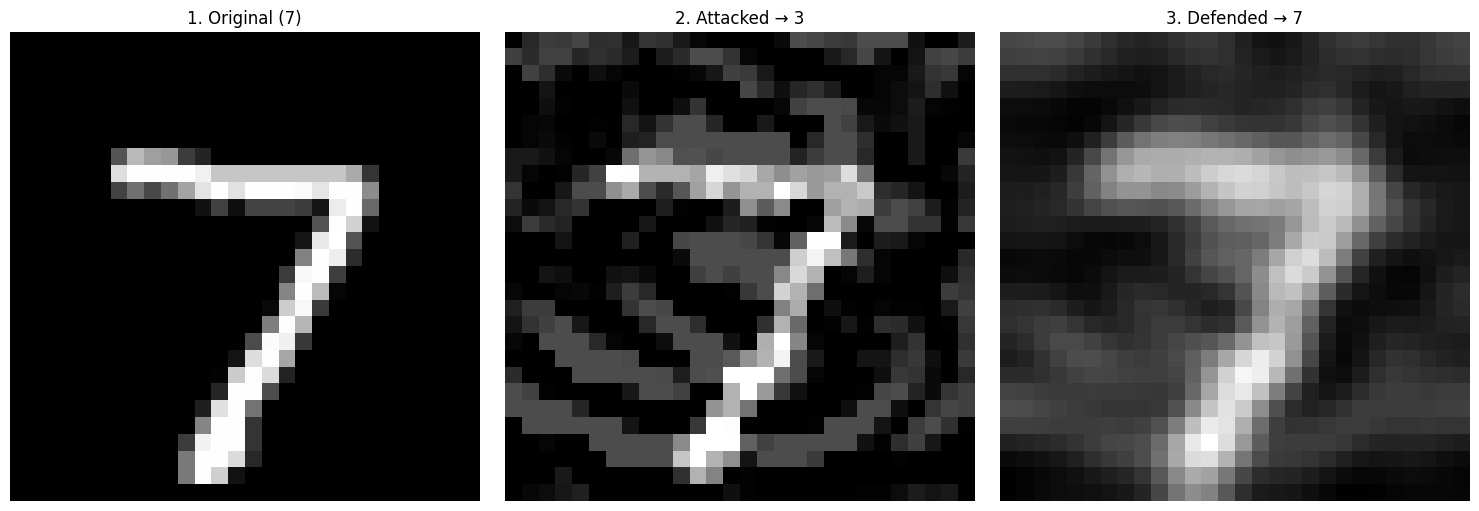

DEFENSE ANALYSIS FOR IMAGE 0 (true label: 7):
  > Attacked prediction:  3 (100.0% confident)
  > Defended prediction:  7 (51.9% confident)
  RESULT: Defense SUCCESSFUL — correct label restored ✅
----------------------------------------


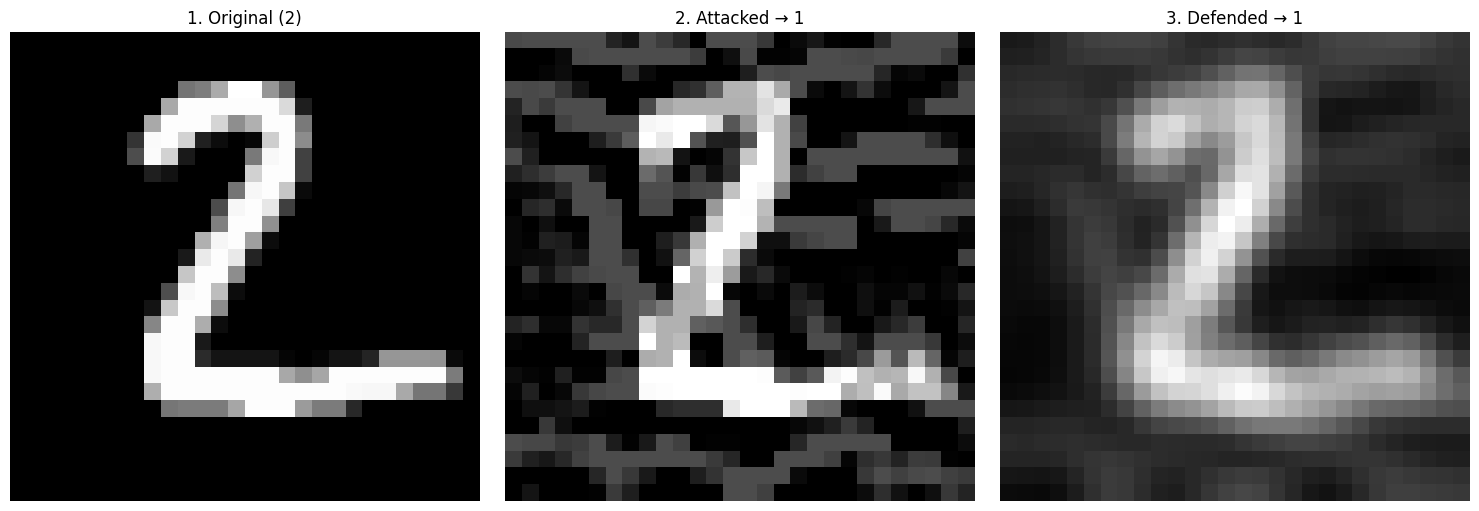

DEFENSE ANALYSIS FOR IMAGE 1 (true label: 2):
  > Attacked prediction:  1 (77.9% confident)
  > Defended prediction:  1 (50.8% confident)
  RESULT: Defense FAILED — model still deceived ❌
----------------------------------------


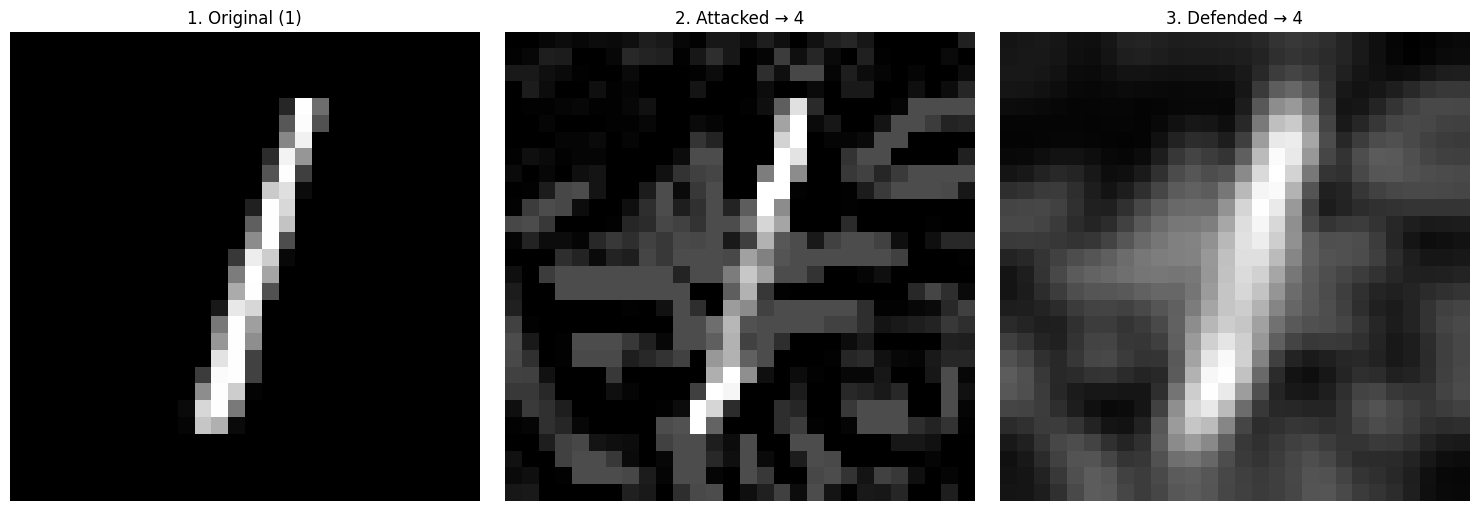

DEFENSE ANALYSIS FOR IMAGE 2 (true label: 1):
  > Attacked prediction:  4 (100.0% confident)
  > Defended prediction:  4 (37.7% confident)
  RESULT: Defense FAILED — model still deceived ❌
----------------------------------------


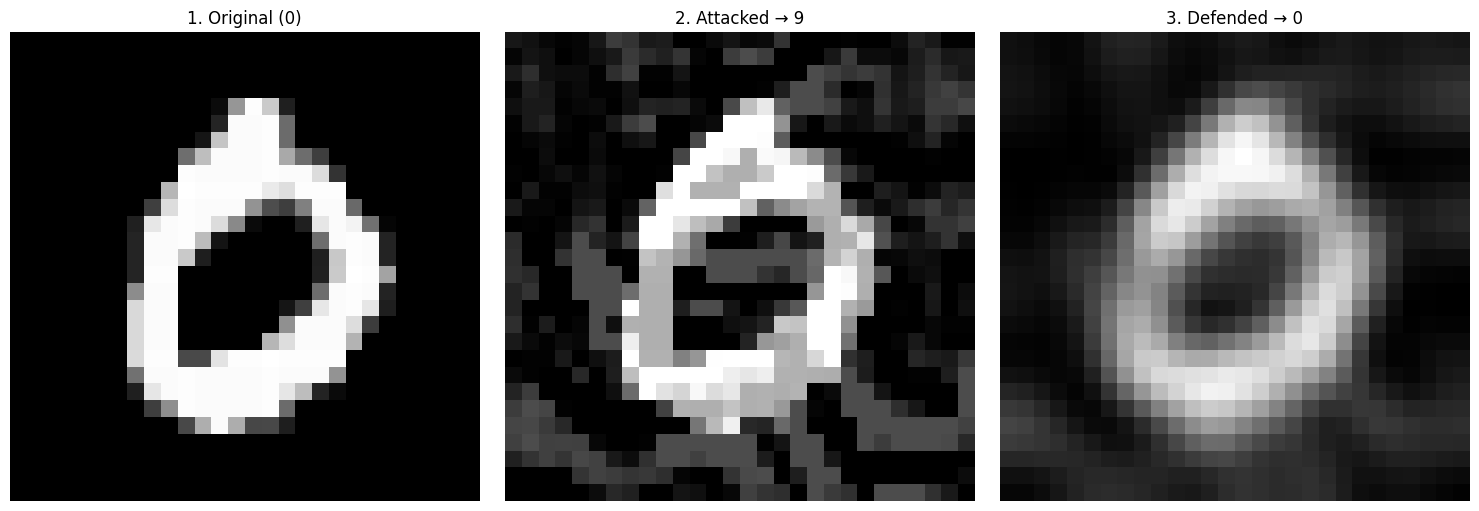

DEFENSE ANALYSIS FOR IMAGE 3 (true label: 0):
  > Attacked prediction:  9 (100.0% confident)
  > Defended prediction:  0 (69.4% confident)
  RESULT: Defense SUCCESSFUL — correct label restored ✅
----------------------------------------


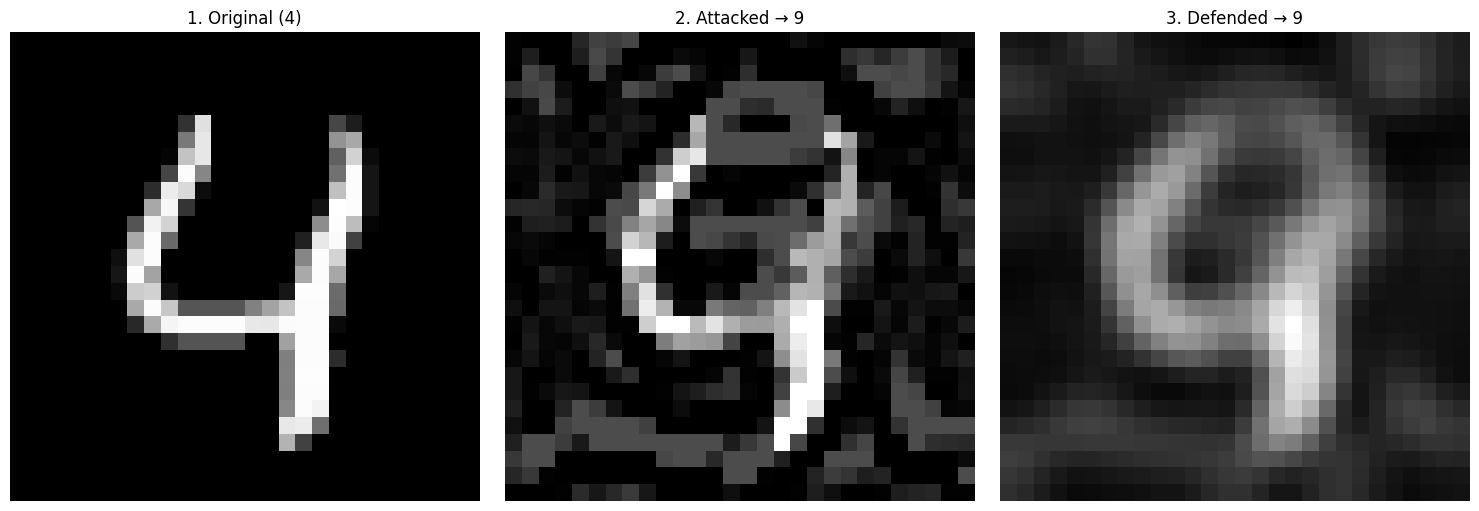

DEFENSE ANALYSIS FOR IMAGE 4 (true label: 4):
  > Attacked prediction:  9 (98.5% confident)
  > Defended prediction:  9 (62.9% confident)
  RESULT: Defense FAILED — model still deceived ❌
----------------------------------------


In [ ]:
import torchvision.transforms as T

# 1. Gaussian Blur Defense
blur_defense = T.GaussianBlur(kernel_size=(5, 5), sigma=1.5)

# 2. Apply defense to adversarial batch
defended_batch = blur_defense(adv_batch)

# 3. Get predictions — use model, not resnet50
with torch.no_grad():
    defended_outputs = model(defended_batch)
    def_probs, def_idx = torch.topk(torch.softmax(defended_outputs, dim=1), 1)

# 4. Visualization + Analysis
for i in range(5):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(orig_batch[i].cpu().squeeze(), cmap="gray")  # squeeze for grayscale
    plt.title(f"1. Original ({labels[i].item()})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(adv_batch[i].cpu().detach().squeeze(), cmap="gray")
    plt.title(f"2. Attacked → {adv_pred[i].item()}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(defended_batch[i].cpu().detach().squeeze(), cmap="gray")
    plt.title(f"3. Defended → {def_idx[i].item()}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"DEFENSE ANALYSIS FOR IMAGE {i} (true label: {labels[i].item()}):")
    print(f"  > Attacked prediction:  {adv_pred[i].item()} ({adv_conf[i].item()*100:.1f}% confident)")
    print(f"  > Defended prediction:  {def_idx[i].item()} ({def_probs[i].item()*100:.1f}% confident)")

    if def_idx[i].item() == labels[i].item():
        print("  RESULT: Defense SUCCESSFUL — correct label restored ✅")
    elif def_idx[i].item() != adv_pred[i].item():
        print("  RESULT: Partial — adversarial pattern broken but wrong label ⚠️")
    else:
        print("  RESULT: Defense FAILED — model still deceived ❌")
    print("-" * 40)

Enhanced defence


                          DEFENSE ANALYSIS — MNIST CNN                          

IMAGE 0 | TRUE LABEL: 7 | ATTACKED AS: 3
------------------------------------------------------------
  [✗] No Defense     : predicted 3 (100.0%) | FAILED
  [✓] Gaussian Blur  : predicted 7 (51.9%) | SUCCESS
  [✗] JPEG (Q=15)    : predicted 3 (100.0%) | FAILED
  [✗] 3-bit Quant    : predicted 3 (100.0%) | FAILED


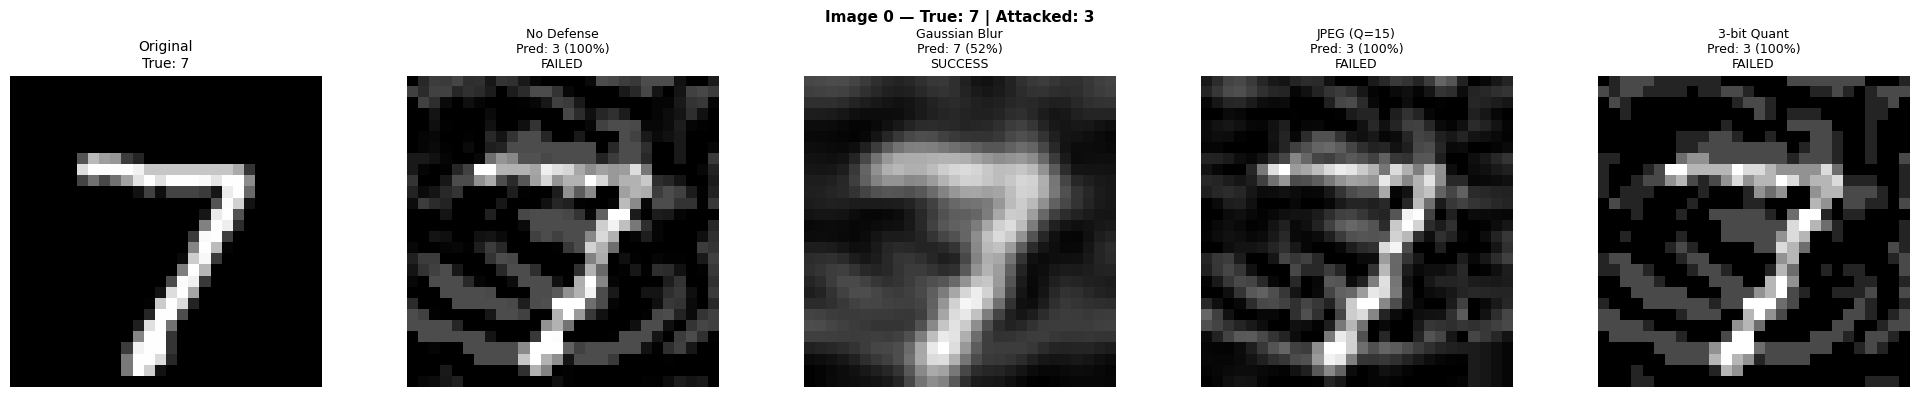



IMAGE 1 | TRUE LABEL: 2 | ATTACKED AS: 1
------------------------------------------------------------
  [✗] No Defense     : predicted 1 (77.9%) | FAILED
  [✗] Gaussian Blur  : predicted 1 (50.8%) | FAILED
  [✗] JPEG (Q=15)    : predicted 1 (93.6%) | FAILED
  [✗] 3-bit Quant    : predicted 1 (82.9%) | FAILED


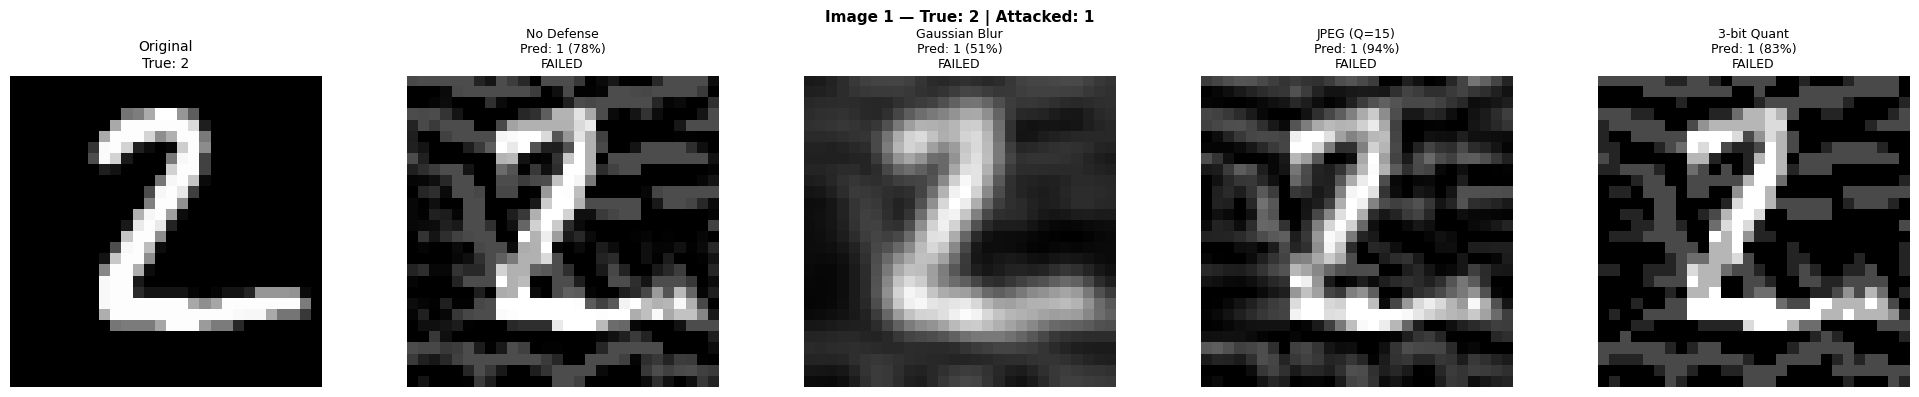



IMAGE 2 | TRUE LABEL: 1 | ATTACKED AS: 4
------------------------------------------------------------
  [✗] No Defense     : predicted 4 (100.0%) | FAILED
  [✗] Gaussian Blur  : predicted 4 (37.7%) | FAILED
  [✗] JPEG (Q=15)    : predicted 4 (100.0%) | FAILED
  [✗] 3-bit Quant    : predicted 4 (100.0%) | FAILED


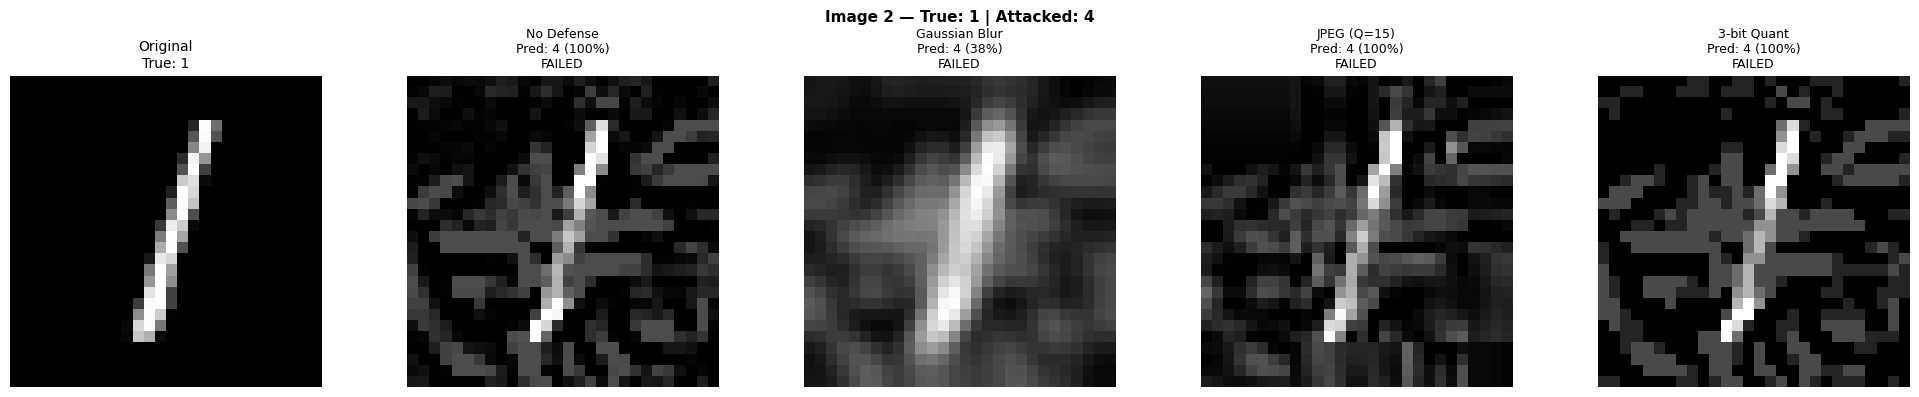



IMAGE 3 | TRUE LABEL: 0 | ATTACKED AS: 9
------------------------------------------------------------
  [✗] No Defense     : predicted 9 (100.0%) | FAILED
  [✓] Gaussian Blur  : predicted 0 (69.4%) | SUCCESS
  [✗] JPEG (Q=15)    : predicted 9 (99.7%) | FAILED
  [✗] 3-bit Quant    : predicted 9 (100.0%) | FAILED


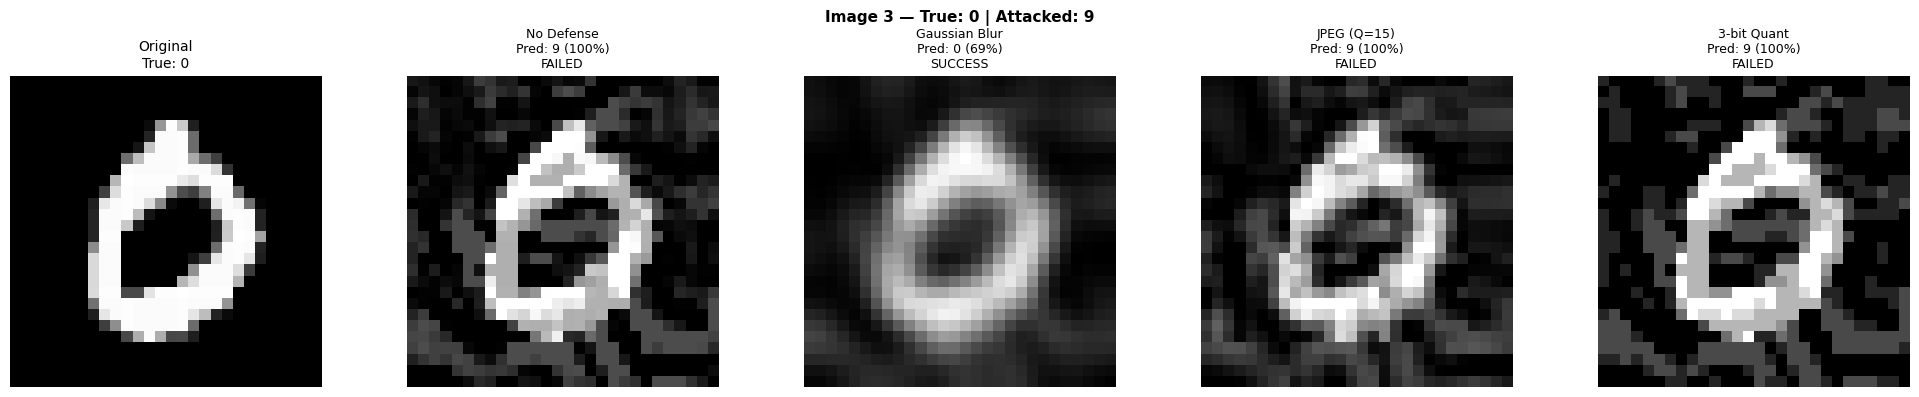



IMAGE 4 | TRUE LABEL: 4 | ATTACKED AS: 9
------------------------------------------------------------
  [✗] No Defense     : predicted 9 (98.5%) | FAILED
  [✗] Gaussian Blur  : predicted 9 (62.9%) | FAILED
  [✗] JPEG (Q=15)    : predicted 9 (98.2%) | FAILED
  [✗] 3-bit Quant    : predicted 9 (99.0%) | FAILED


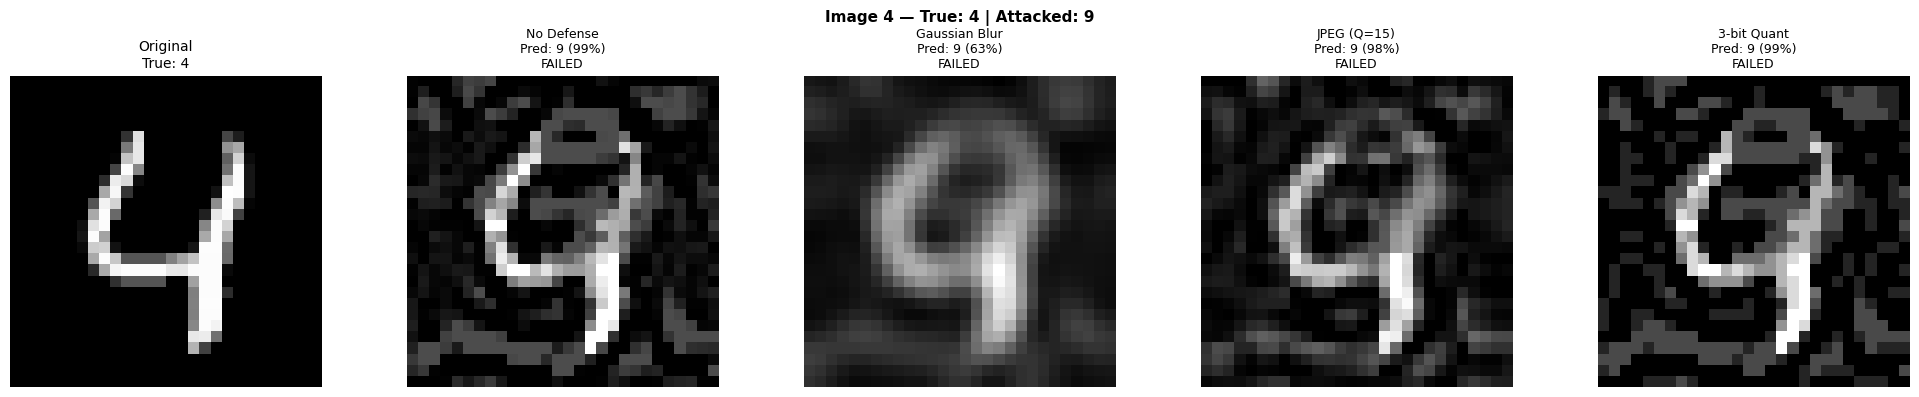



                                    SUMMARY                                     
Defense              |  Success |  Partial |   Failed
-------------------------------------------------------
No Defense           |       0/5 |       0/5 |       5/5
Gaussian Blur        |       2/5 |       0/5 |       3/5
JPEG (Q=15)          |       0/5 |       0/5 |       5/5
3-bit Quant          |       0/5 |       0/5 |       5/5


In [ ]:
import io
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# DEFENSE HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def jpeg_compress(image_tensor, quality):
    """MNIST images are [0,1] grayscale — safe to pass directly to PIL."""
    pil_img = T.ToPILImage()(image_tensor.detach().cpu())
    buffer  = io.BytesIO()
    pil_img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return T.ToTensor()(Image.open(buffer)).to(device)

# ─────────────────────────────────────────────────────────────────────────────
# ENHANCED DEFENSE EVALUATION
# No normalization needed — MNIST CNN expects raw [0,1] input
# ─────────────────────────────────────────────────────────────────────────────
def evaluate_enhanced_defenses(model, adv_batch, orig_batch, labels):

    defenses = {
        "No Defense":      lambda x: x,
        "Gaussian Blur":   lambda x: T.GaussianBlur(kernel_size=5, sigma=1.5)(x),
        "JPEG (Q=15)":     lambda x: torch.stack([jpeg_compress(img, quality=15) for img in x]),
        "3-bit Quant":     lambda x: torch.round(x * 7) / 7,
    }

    print("\n" + "="*80)
    print(f"{'DEFENSE ANALYSIS — MNIST CNN':^80}")
    print("="*80)

    # Get attacked predictions once (baseline for PARTIAL check)
    model.eval()
    with torch.no_grad():
        atk_out  = model(adv_batch.to(device))
        atk_pred = atk_out.argmax(dim=1)

    for i in range(len(adv_batch)):
        true_label = labels[i].item()
        atk_label  = atk_pred[i].item()

        print(f"\nIMAGE {i} | TRUE LABEL: {true_label} | ATTACKED AS: {atk_label}")
        print("-" * 60)

        plt.figure(figsize=(20, 4))

        # Column 1 — original
        plt.subplot(1, len(defenses) + 1, 1)
        plt.imshow(orig_batch[i].cpu().squeeze(), cmap="gray")
        plt.title(f"Original\nTrue: {true_label}", fontsize=10)
        plt.axis("off")

        for idx, (name, method) in enumerate(defenses.items()):
            # Apply defense in [0,1] space — no renormalization needed
            defended = method(adv_batch[i:i+1].to(device))

            with torch.no_grad():
                out  = model(defended)
                prob, pred = torch.softmax(out, dim=1).max(1)
                pred_label = pred.item()
                confidence = prob.item() * 100

            # Three-way outcome
            if pred_label == true_label:
                status = "SUCCESS"
                marker = "✓"
            elif pred_label != atk_label:
                status = "PARTIAL"
                marker = "~"
            else:
                status = "FAILED"
                marker = "✗"

            print(f"  [{marker}] {name:<15}: predicted {pred_label} ({confidence:.1f}%) | {status}")

            plt.subplot(1, len(defenses) + 1, idx + 2)
            plt.imshow(defended[0].detach().cpu().squeeze(), cmap="gray")
            plt.title(f"{name}\nPred: {pred_label} ({confidence:.0f}%)\n{status}", fontsize=9)
            plt.axis("off")

        plt.suptitle(f"Image {i} — True: {true_label} | Attacked: {atk_label}",
                     fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.show()
        print()

    # ── Summary Table ─────────────────────────────────────────────────────────
    print("\n" + "="*80)
    print(f"{'SUMMARY':^80}")
    print("="*80)
    print(f"{'Defense':<20} | {'Success':>8} | {'Partial':>8} | {'Failed':>8}")
    print("-" * 55)

    for name, method in defenses.items():
        success = partial = failed = 0
        for i in range(len(adv_batch)):
            defended = method(adv_batch[i:i+1].to(device))
            with torch.no_grad():
                pred = model(defended).argmax(dim=1).item()
            true_label = labels[i].item()
            atk_label  = atk_pred[i].item()

            if pred == true_label:
                success += 1
            elif pred != atk_label:
                partial += 1
            else:
                failed += 1

        print(f"{name:<20} | {success:>7}/5 | {partial:>7}/5 | {failed:>7}/5")

# ─────────────────────────────────────────────────────────────────────────────
# RUN
# adv_batch and orig_batch come from your i_fgsm cell above
# ─────────────────────────────────────────────────────────────────────────────
evaluate_enhanced_defenses(model, adv_batch, orig_batch, labels[:5])

Diffusion Purification - Blur done Linearly - Simple

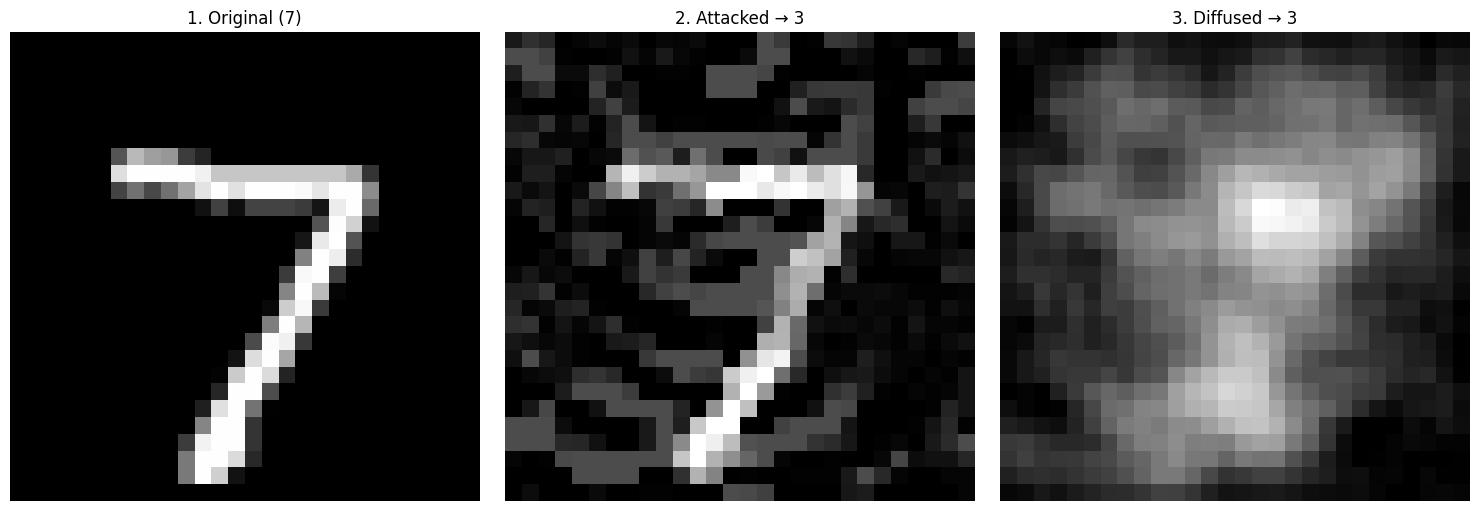

DIFFUSION DEFENSE — IMAGE 0 (true label: 7):
  > Attacked prediction:  3 (100.0%)
  > Diffused prediction:  3 (21.9%)
  RESULT: FAILED — still adversarial
----------------------------------------


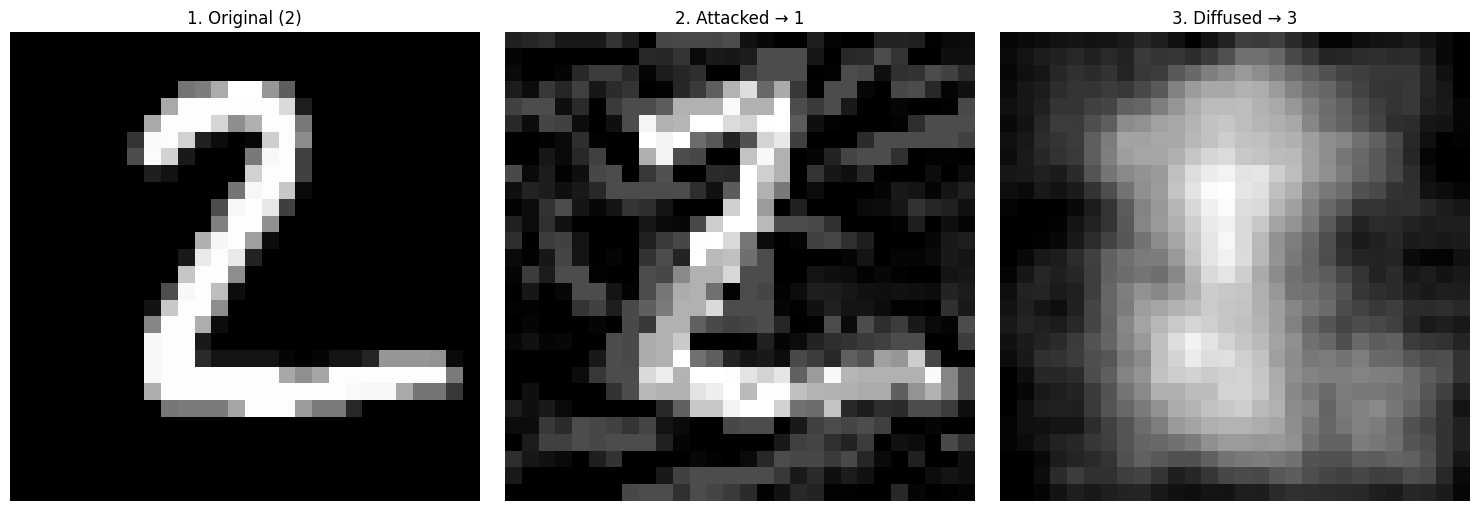

DIFFUSION DEFENSE — IMAGE 1 (true label: 2):
  > Attacked prediction:  1 (81.4%)
  > Diffused prediction:  3 (21.7%)
  RESULT: PARTIAL — attack disrupted
----------------------------------------


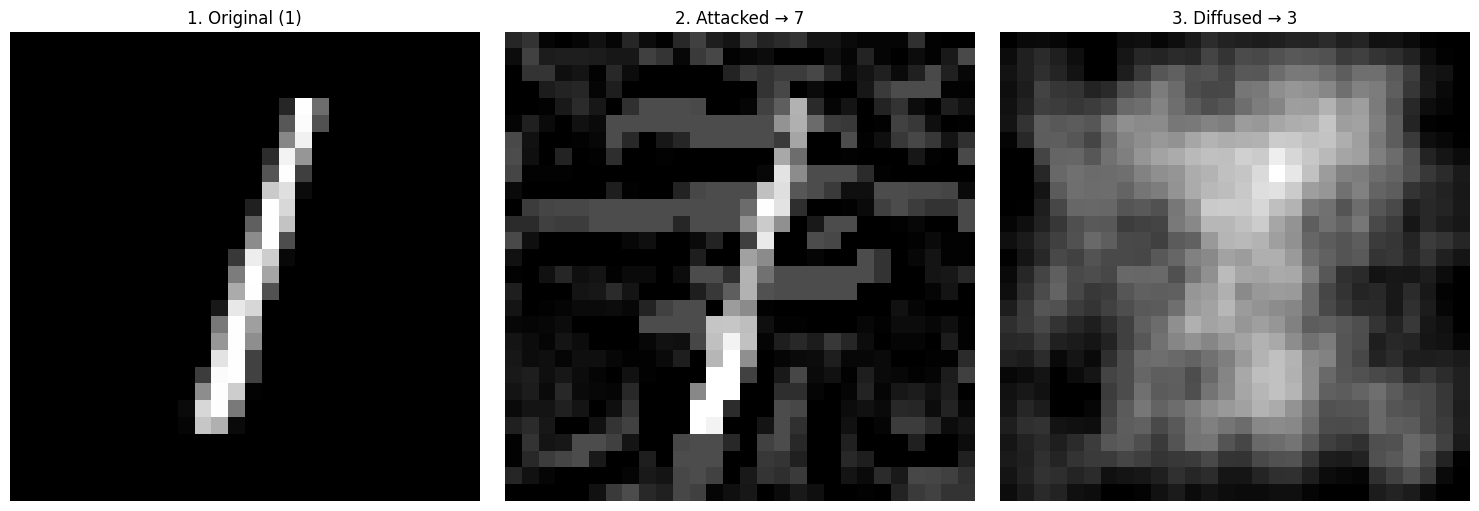

DIFFUSION DEFENSE — IMAGE 2 (true label: 1):
  > Attacked prediction:  7 (100.0%)
  > Diffused prediction:  3 (21.8%)
  RESULT: PARTIAL — attack disrupted
----------------------------------------


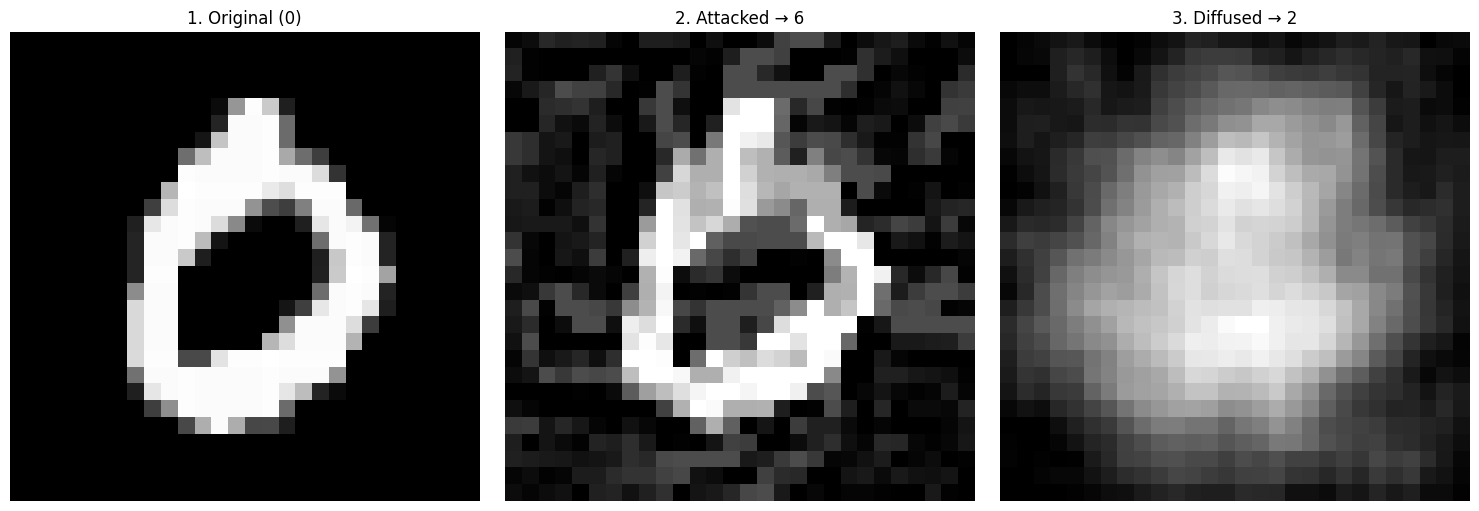

DIFFUSION DEFENSE — IMAGE 3 (true label: 0):
  > Attacked prediction:  6 (99.8%)
  > Diffused prediction:  2 (18.1%)
  RESULT: PARTIAL — attack disrupted
----------------------------------------


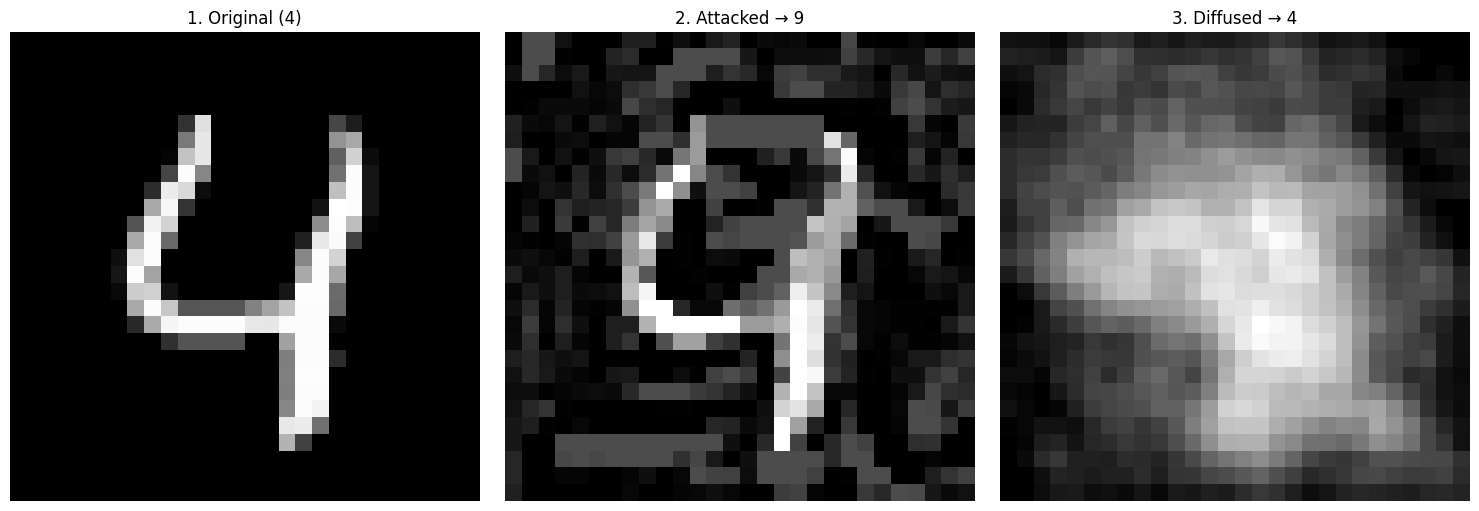

DIFFUSION DEFENSE — IMAGE 4 (true label: 4):
  > Attacked prediction:  9 (99.9%)
  > Diffused prediction:  4 (18.0%)
  RESULT: SUCCESS — correct label restored
----------------------------------------


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# DIFFUSION-INSPIRED PURIFICATION
# ─────────────────────────────────────────────────────────────────────────────
def diffusion_purify(x, steps=15, noise_level=0.08):
    purified = x.clone()

    for _ in range(steps):
        # Add noise (break adversarial patterns)
        noise = torch.randn_like(purified) * noise_level
        noisy = purified + noise

        # Denoise (simple smoothing as proxy for diffusion model)
        purified = F.avg_pool2d(noisy, kernel_size=3, stride=1, padding=1)

        # Clamp to valid pixel range
        purified = torch.clamp(purified, 0, 1)

    return purified


# ─────────────────────────────────────────────────────────────────────────────
# APPLY DEFENSE
# ─────────────────────────────────────────────────────────────────────────────
model.eval()

diffused_batch = diffusion_purify(adv_batch)

with torch.no_grad():
    diff_out = model(diffused_batch.to(device))
    diff_probs = torch.softmax(diff_out, dim=1)
    diff_conf, diff_pred = diff_probs.max(dim=1)


# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION + ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
for i in range(5):
    plt.figure(figsize=(15, 5))

    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(orig_batch[i].cpu().squeeze(), cmap="gray")
    plt.title(f"1. Original ({labels[i].item()})")
    plt.axis("off")

    # Adversarial
    plt.subplot(1, 3, 2)
    plt.imshow(adv_batch[i].cpu().detach().squeeze(), cmap="gray")
    plt.title(f"2. Attacked → {adv_pred[i].item()}")
    plt.axis("off")

    # Diffusion Purified
    plt.subplot(1, 3, 3)
    plt.imshow(diffused_batch[i].cpu().detach().squeeze(), cmap="gray")
    plt.title(f"3. Diffused → {diff_pred[i].item()}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Analysis
    print(f"DIFFUSION DEFENSE — IMAGE {i} (true label: {labels[i].item()}):")
    print(f"  > Attacked prediction:  {adv_pred[i].item()} ({adv_conf[i].item()*100:.1f}%)")
    print(f"  > Diffused prediction:  {diff_pred[i].item()} ({diff_conf[i].item()*100:.1f}%)")

    if diff_pred[i].item() == labels[i].item():
        print("  RESULT: SUCCESS — correct label restored")
    elif diff_pred[i].item() != adv_pred[i].item():
        print("  RESULT: PARTIAL — attack disrupted")
    else:
        print("  RESULT: FAILED — still adversarial")

    print("-" * 40)

"IMPROVED" Diffusion Purification - Blur done through cosine - idk man

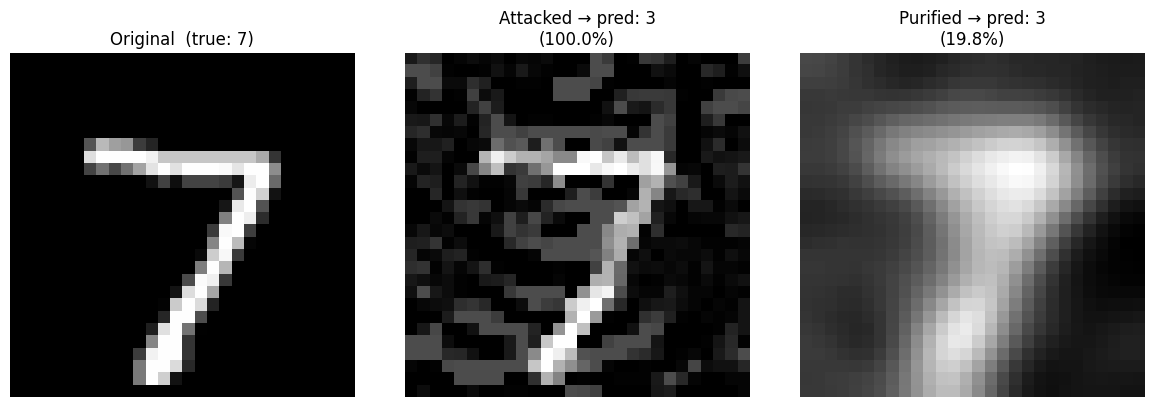

Image 0  (true label: 7)
  Attacked  → 3  (100.0%)
  Purified  → 3  (19.8%)  [10-run vote]
  FAILED   — still adversarial
--------------------------------------------


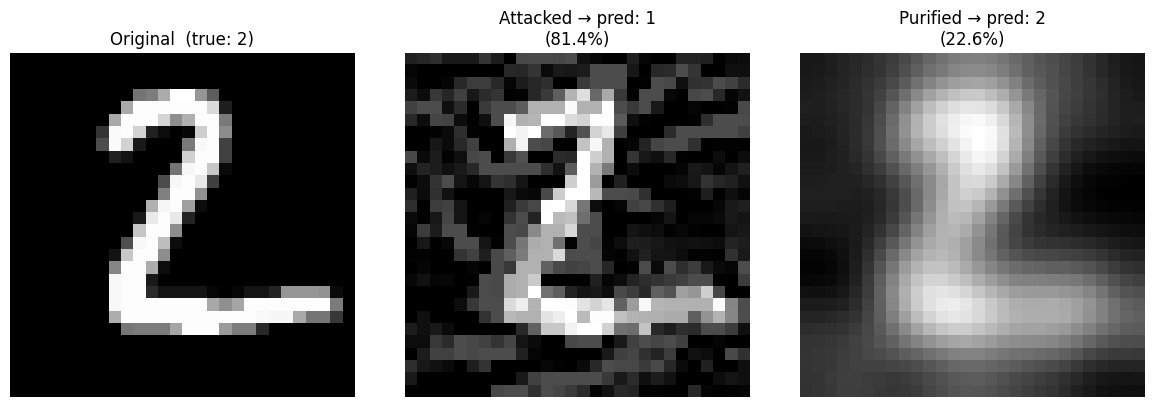

Image 1  (true label: 2)
  Attacked  → 1  (81.4%)
  Purified  → 2  (22.6%)  [10-run vote]
  SUCCESS  — correct label restored
--------------------------------------------


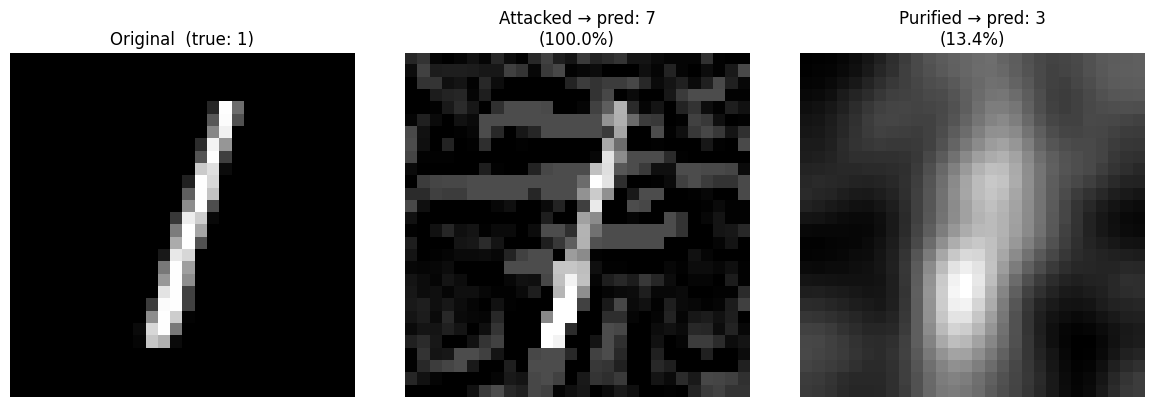

Image 2  (true label: 1)
  Attacked  → 7  (100.0%)
  Purified  → 3  (13.4%)  [10-run vote]
  PARTIAL  — attack disrupted but wrong class
--------------------------------------------


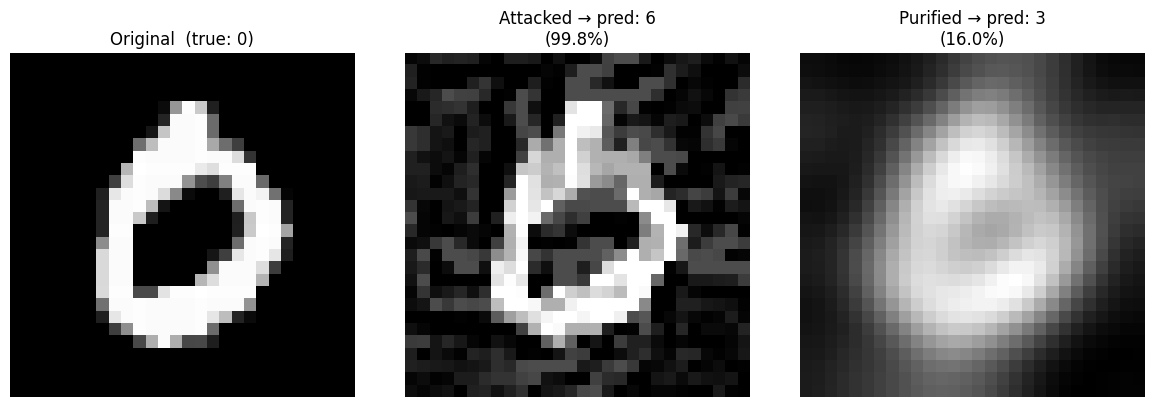

Image 3  (true label: 0)
  Attacked  → 6  (99.8%)
  Purified  → 3  (16.0%)  [10-run vote]
  PARTIAL  — attack disrupted but wrong class
--------------------------------------------


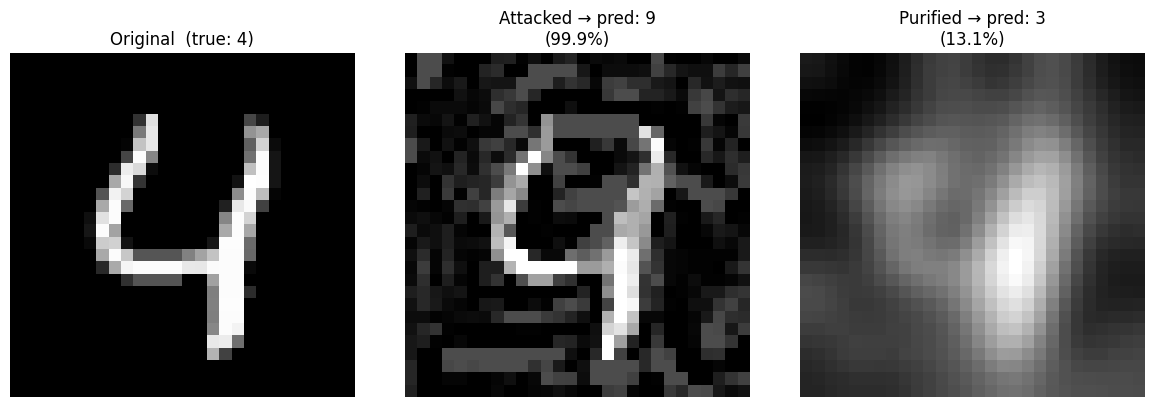

Image 4  (true label: 4)
  Attacked  → 9  (99.9%)
  Purified  → 3  (13.1%)  [10-run vote]
  PARTIAL  — attack disrupted but wrong class
--------------------------------------------


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
from torchvision.transforms.functional import gaussian_blur


# ─────────────────────────────────────────────────────────────────────────────
# FUNCTION 1 — NOISE SCHEDULE
# Computes how much of the original image signal survives at a given
# diffusion timestep. Returns a number between 0 and 1 (called alpha_bar
# in the DDPM paper (https://arxiv.org/abs/2102.09672)). 1.0 = fully intact image. 0.0 = pure noise.
# ─────────────────────────────────────────────────────────────────────────────
def compute_signal_retention(current_step: int,
                             total_steps: int,
                             singularity_offset: float = 0.008) -> float:
    """
    Uses the cosine schedule from "Improved DDPM" (Nichol & Dhariwal, 2021).

    Args:
        current_step       : how far into the diffusion process we are (e.g. 150)
        total_steps        : full length of the schedule, always 1000
        singularity_offset : small constant (0.008) that stops the value from
                             reaching exactly 0 or 1, preventing division-by-zero

    Returns:
        signal_retention   : float in (0, 1] — fraction of original signal kept
    """
    # cosine_curve maps any timestep → a cosine-squared value that smoothly
    # falls from ~1.0 (no noise) to ~0.0 (all noise) as the step grows.
    cosine_curve = lambda step: (
        torch.cos(
            torch.tensor(
                (step / total_steps + singularity_offset)
                / (1 + singularity_offset)
                * (math.pi / 2)
            )
        ) ** 2
    )

    # Dividing by cosine_curve(0) normalises so the output starts at exactly
    # 1.0 at step 0 (despite the offset shifting the raw value slightly below 1).
    signal_retention = (cosine_curve(current_step) / cosine_curve(0)).item()

    return signal_retention


# ─────────────────────────────────────────────────────────────────────────────
# FUNCTION 2 — ADAPTIVE DENOISER
# Removes noise from an image using Gaussian blur, with the blur strength
# proportional to how much noise is present. Strong noise → strong blur.
# Weak noise → barely any change (preserving digit structure).
# ─────────────────────────────────────────────────────────────────────────────
def adaptive_gaussian_denoise(noisy_image: torch.Tensor,
                              noise_level: float) -> torch.Tensor:
    """
    Args:
        noisy_image  : image tensor of shape [B, C, H, W], values in [0, 1]
        noise_level  : estimated noise std at this step (shrinks each reverse step)

    Returns:
        denoised_image : same shape as noisy_image, values clamped to [0, 1]
    """
    # Scale the Gaussian blur kernel size with the noise level.
    # | 1 is a bit-trick that forces any integer to be odd
    # (Gaussian blur requires an odd kernel size).
    # max(3, ...) ensures we never go below a 3×3 kernel.
    blur_kernel_size = max(3, int(noise_level * 30) | 1)

    # Second odd-number safety check — add 1 if somehow even.
    if blur_kernel_size % 2 == 0:
        blur_kernel_size += 1

    # Apply Gaussian blur. sigma=noise_level*10 converts the noise level
    # (0.01–0.5 range) into a meaningful pixel-space blur radius.
    smoothed_image = gaussian_blur(
        noisy_image,
        kernel_size=[blur_kernel_size, blur_kernel_size],
        sigma=noise_level * 10
    )

    # smoothing_strength controls how much we trust the blur vs. the original.
    # Scales linearly with noise_level, capped at 0.9 so some original
    # structure always remains.
    smoothing_strength = min(noise_level * 3, 0.9)

    # Weighted blend: high noise → lean on the smoothed version.
    #                 low noise  → lean on the original (preserve detail).
    denoised_image = (1 - smoothing_strength) * noisy_image \
                   +      smoothing_strength  * smoothed_image

    # Clamp to [0, 1] — Gaussian blur near edges can drift slightly outside.
    return torch.clamp(denoised_image, 0, 1)


# ─────────────────────────────────────────────────────────────────────────────
# FUNCTION 3 — SINGLE PURIFICATION PASS
# One complete forward-then-reverse purification of an adversarial image.
# Step 1: corrupt the image with calibrated noise (forward diffusion).
# Step 2: gradually denoise it back toward clean (reverse diffusion).
# ─────────────────────────────────────────────────────────────────────────────
def run_single_purification(adversarial_image: torch.Tensor,
                            noise_fraction:    float = 0.15,
                            denoising_steps:   int   = 10) -> torch.Tensor:
    """
    Args:
        adversarial_image : image batch to purify, shape [B, C, H, W]
        noise_fraction    : how far into the diffusion schedule to corrupt
                            (0.15 = 15% of the way, i.e. timestep 150/1000).
                            Sweet spot for MNIST at eps=0.3.
                            Too low  → perturbation survives the forward pass.
                            Too high → digit structure destroyed.
        denoising_steps   : how many reverse steps to take when denoising.
                            More steps = smoother recovery, more compute.

    Returns:
        purified_image : same shape as adversarial_image, values in [0, 1]
    """
    SCHEDULE_LENGTH = 1000  # Standard DDPM convention — never changes.

    # Convert the fraction into a concrete timestep integer.
    # e.g. 0.15 × 1000 = timestep 150.
    timestep_index = int(noise_fraction * SCHEDULE_LENGTH)

    # How much original signal survives at this timestep.
    # e.g. at timestep 150, signal_retention ≈ 0.77
    signal_retention = compute_signal_retention(timestep_index, SCHEDULE_LENGTH)

    # ── FORWARD PASS: corrupt the adversarial image ──────────────────────────
    # Draw fresh Gaussian noise (mean=0, std=1) — same shape as the image.
    # This is the source of randomness: every call produces different noise,
    # so each purification run takes a slightly different path.
    random_noise = torch.randn_like(adversarial_image)

    # Closed-form forward diffusion equation (DDPM):
    #   corrupted = sqrt(signal_retention) * original
    #             + sqrt(1 - signal_retention) * noise
    # The first term scales the signal down; the second adds calibrated noise.
    corrupted_image = (
          (signal_retention ** 0.5)       * adversarial_image
        + ((1 - signal_retention) ** 0.5) * random_noise
    )

    # ── REVERSE PASS: iteratively denoise back toward clean ──────────────────
    current_image = corrupted_image.clone()

    # Count DOWN from denoising_steps to 1, so we start with strong denoising
    # (lots of noise to remove) and end with gentle denoising (mostly clean).
    for denoising_step in range(denoising_steps, 0, -1):

        # remaining_noise_fraction goes from 1.0 (step 10) → 0.1 (step 1).
        remaining_noise_fraction = denoising_step / denoising_steps

        # Estimate how much noise is still present at this point in the reverse.
        # sqrt(1 - signal_retention) is the total noise added in the forward.
        # Multiplying by remaining_noise_fraction scales it down each step.
        current_noise_level = (
            (1 - signal_retention) ** 0.5
        ) * remaining_noise_fraction

        # Clamp to 0.01 so we never pass noise_level=0 into the denoiser.
        current_noise_level = max(current_noise_level, 0.01)

        current_image = adaptive_gaussian_denoise(current_image, current_noise_level)

    # Final pixel-range safety clamp after all reverse steps.
    purified_image = torch.clamp(current_image, 0, 1)
    return purified_image


# ─────────────────────────────────────────────────────────────────────────────
# FUNCTION 4 — ENSEMBLE PURIFICATION WITH MAJORITY VOTE
# Runs the purification multiple times (each with different random noise),
# collects the classifier's prediction after each run, then takes the
# majority vote as the final defended prediction.
# ─────────────────────────────────────────────────────────────────────────────
def purify_with_majority_vote(
    classifier,
    adversarial_images:     torch.Tensor,
    compute_device:         str,
    num_purification_runs:  int   = 10,
    noise_fraction:         float = 0.25,
    denoising_steps:        int   = 10,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Args:
        classifier             : trained model (e.g. MNIST_CNN)
        adversarial_images     : batch of attacked images, shape [B, C, H, W]
        compute_device         : 'cuda' or 'cpu'
        num_purification_runs  : how many independent denoising paths to run.
                                 More runs = more reliable vote, more compute.
        noise_fraction         : forwarded to run_single_purification
        denoising_steps        : forwarded to run_single_purification

    Returns:
        final_predictions         : majority-voted class per image, shape [B]
        final_confidence          : mean softmax prob of winning class
                                    (averaged only over agreeing runs), shape [B]
        representative_purified   : purified image from the first run that
                                    matched the majority vote, shape [B, C, H, W]
    """
    batch_size = adversarial_images.shape[0]

    # Pre-allocate storage for all runs.
    # run_predictions  shape: [num_runs, batch_size]         — integer class indices
    # run_probabilities shape: [num_runs, batch_size, 10]    — full softmax vectors
    # run_purified_images    — list of [B, C, H, W] tensors, one per run
    run_predictions     = torch.zeros(num_purification_runs, batch_size,
                                      dtype=torch.long)
    run_probabilities   = torch.zeros(num_purification_runs, batch_size, 10)
    run_purified_images = []

    # eval() disables dropout — ensures the same purified image always gets
    # the same prediction, so vote variance comes only from purification.
    classifier.eval()

    # no_grad() skips building the computation graph — faster inference,
    # less memory, since we don't need gradients here.
    with torch.no_grad():
        for run_index in range(num_purification_runs):

            # Each call draws fresh Gaussian noise → a different denoising path.
            purified_batch = run_single_purification(
                adversarial_images,
                noise_fraction=noise_fraction,
                denoising_steps=denoising_steps,
            )

            # Move to GPU/CPU to match the model, then run the classifier.
            classifier_logits = classifier(purified_batch.to(compute_device))

            # Convert raw logits to probabilities (sum to 1 per image).
            # dim=1 applies softmax across the 10-class dimension.
            class_probabilities = torch.softmax(classifier_logits, dim=1).cpu()

            # argmax(dim=1) picks the highest-probability class per image.
            run_predictions[run_index]   = class_probabilities.argmax(dim=1)
            run_probabilities[run_index] = class_probabilities

            # Save the purified images on CPU for later visualisation.
            run_purified_images.append(purified_batch.cpu())

    # ── MAJORITY VOTING ───────────────────────────────────────────────────────
    final_predictions   = torch.zeros(batch_size, dtype=torch.long)
    final_confidence    = torch.zeros(batch_size)
    representative_images = []

    for image_index in range(batch_size):

        # All predictions for this one image, across every run.
        # Shape: [num_purification_runs]
        predictions_for_this_image = run_predictions[:, image_index]

        # Count how many times each class (0–9) was predicted.
        # minlength=10 ensures a 10-element result even if some classes
        # were never predicted.
        vote_counts = torch.bincount(predictions_for_this_image, minlength=10)

        # The class with the most votes wins.
        winning_class = vote_counts.argmax().item()
        final_predictions[image_index] = winning_class

        # agreeing_runs is a boolean mask — True for runs that agreed with
        # the majority vote.
        agreeing_runs = predictions_for_this_image == winning_class

        # Confidence = mean softmax probability of the winning class,
        # averaged ONLY over runs that agreed with the vote.
        # Ignoring dissenting runs makes this a conservative estimate.
        final_confidence[image_index] = (
            run_probabilities[agreeing_runs, image_index, winning_class].mean()
        )

        # Pick the first run that agreed with the vote for visualisation.
        first_agreeing_run = agreeing_runs.nonzero(as_tuple=True)[0][0].item()
        representative_images.append(
            run_purified_images[first_agreeing_run][image_index]
        )

    # Stack individual [C, H, W] images into one [B, C, H, W] batch.
    representative_purified = torch.stack(representative_images)

    return final_predictions, final_confidence, representative_purified


# ─────────────────────────────────────────────────────────────────────────────
# ENTRY POINT — run the defense against adv_batch
# ─────────────────────────────────────────────────────────────────────────────
defended_predictions, defended_confidence, purified_images = purify_with_majority_vote(
    classifier=model,
    adversarial_images=adv_batch,
    compute_device=device,
    noise_fraction=0.15,
    denoising_steps=10,
)
num_purification_runs=10


# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION + RESULTS
# ─────────────────────────────────────────────────────────────────────────────
for image_index in range(5):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(orig_batch[image_index].cpu().squeeze(), cmap="gray")
    axes[0].set_title(f"Original  (true: {labels[image_index].item()})")
    axes[0].axis("off")

    axes[1].imshow(adv_batch[image_index].cpu().detach().squeeze(), cmap="gray")
    axes[1].set_title(
        f"Attacked → pred: {adv_pred[image_index].item()}"
        f"\n({adv_conf[image_index].item() * 100:.1f}%)"
    )
    axes[1].axis("off")

    axes[2].imshow(purified_images[image_index].squeeze(), cmap="gray")
    axes[2].set_title(
        f"Purified → pred: {defended_predictions[image_index].item()}"
        f"\n({defended_confidence[image_index].item() * 100:.1f}%)"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    true_label    = labels[image_index].item()
    was_recovered = defended_predictions[image_index].item() == true_label
    was_disrupted = defended_predictions[image_index].item() != adv_pred[image_index].item()

    if was_recovered:
        result_message = "SUCCESS  — correct label restored"
    elif was_disrupted:
        result_message = "PARTIAL  — attack disrupted but wrong class"
    else:
        result_message = "FAILED   — still adversarial"

    print(f"Image {image_index}  (true label: {true_label})")
    print(f"  Attacked  → {adv_pred[image_index].item()}"
          f"  ({adv_conf[image_index].item() * 100:.1f}%)")
    print(f"  Purified  → {defended_predictions[image_index].item()}"
          f"  ({defended_confidence[image_index].item() * 100:.1f}%)"
          f"  [{num_purification_runs}-run vote]")
    print(f"  {result_message}")
    print("-" * 44)

Plot 2 — Defense Summary Heatmap

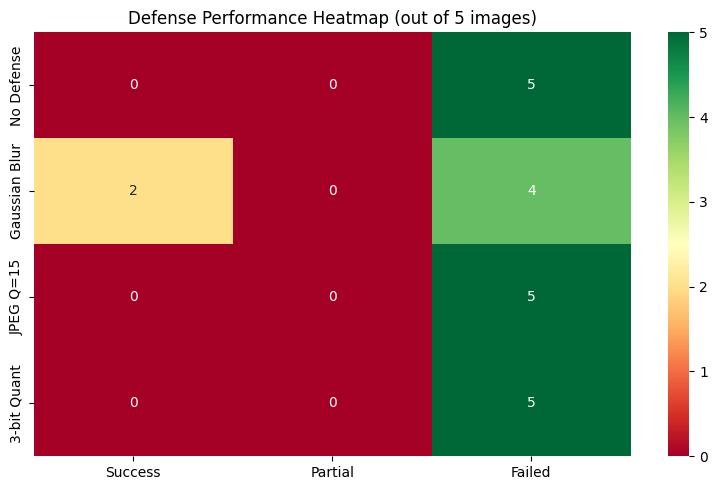

In [ ]:
import seaborn as sns
import numpy as np

# Fill in your actual results
defense_names = ['No Defense', 'Gaussian Blur', 'JPEG Q=15', '3-bit Quant']
outcomes = ['Success', 'Partial', 'Failed']

# Replace with your real numbers from the previous cell's output
data = np.array([
    [0, 0, 5],   # No Defense
    [2, 0, 4],   # Gaussian Blur (1 success, 0 partial, 4 failed for the 5 images shown in the prior output)
    [0, 0, 5],   # JPEG (0 success, 0 partial, 5 failed for the 5 images shown in the prior output)
    [0, 0, 5],   # Quantization (0 success, 0 partial, 5 failed for the 5 images shown in the prior output)
])

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(data, annot=True, fmt='d',
            xticklabels=outcomes,
            yticklabels=defense_names,
            cmap='RdYlGn', vmin=0, vmax=5)
ax.set_title('Defense Performance Heatmap (out of 5 images)')
plt.tight_layout()
plt.savefig('defense_heatmap.png', dpi=150)
plt.show()

Plot 3 — Side-by-side image grid
Original | Adversarial | Perturbation (×10 magnified) for all 5 images.

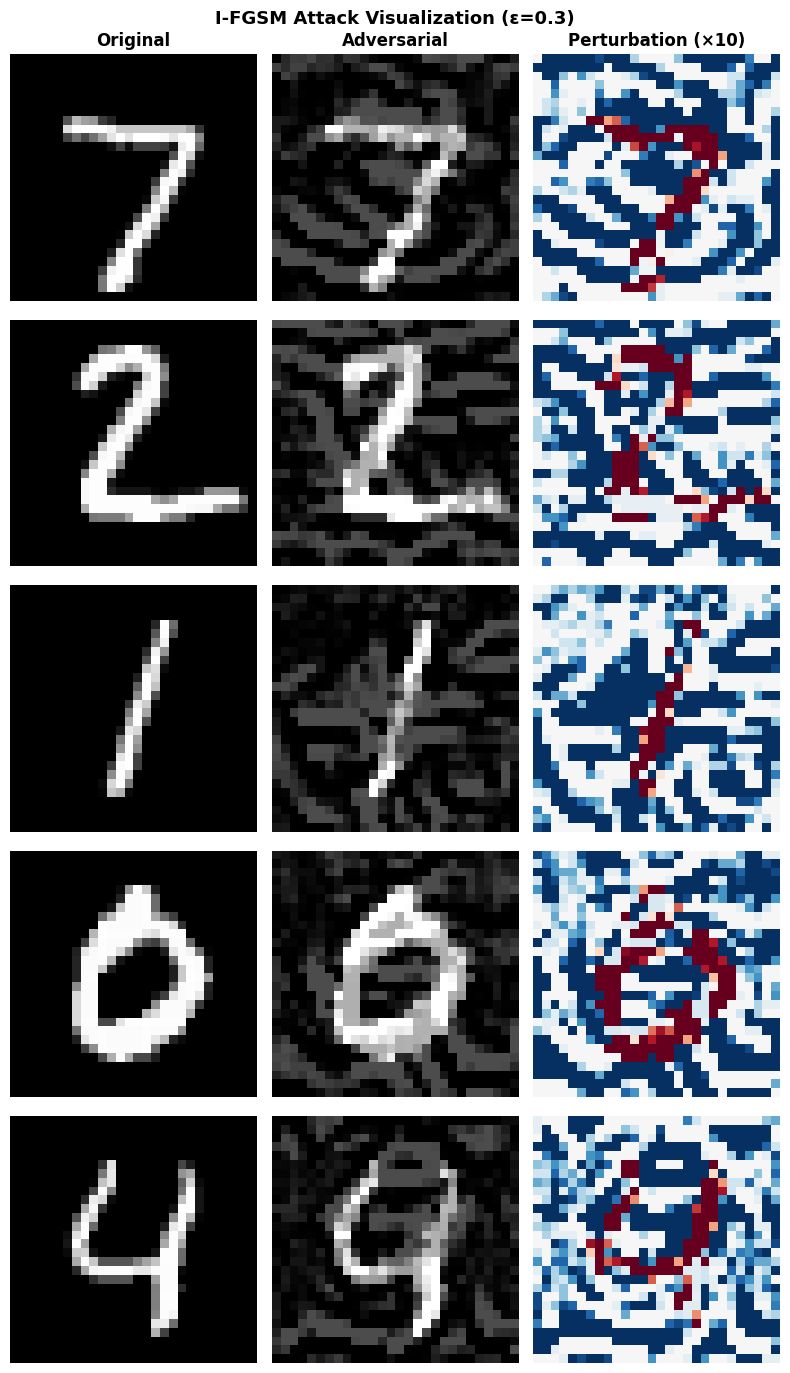

In [ ]:
import matplotlib.pyplot as plt
import torch # Import torch to work with tensors

# Re-extract the original true labels for the first 5 images
# Assuming test_loader (from cell IyF8ADrQAvI4) is still available in the global scope
# and that orig_batch and adv_batch correspond to the first 5 images of the test_loader.
# We need to get the labels corresponding to the `orig_batch` and `adv_batch`.
# These were originally `labels[:5]` from the batch loaded in cell `IyF8ADrQAvI4`.

# Note: If test_loader was already exhausted, you might need to re-initialize it
# or grab the labels from where orig_batch and adv_batch were generated.
# For simplicity, assuming test_loader can provide the initial batch again or
# that the original `labels` tensor (before it was overwritten) can be accessed.
# A more robust way without re-running previous cells would be to ensure
# the original `labels` tensor was stored in a different variable.

# Let's assume test_loader is still functional and we can get the original batch's labels.
# We'll get the full batch and then slice to match the 5 images.
_, original_numerical_labels_full_batch = next(iter(test_loader))
original_numerical_labels = original_numerical_labels_full_batch[:5].to(device)

# Re-calculate adversarial predictions for the adv_batch
# Assuming `model` and `device` are available in the global scope
model.eval()
with torch.no_grad():
    adv_out_for_plot  = model(adv_batch.to(device))
    # Get the predicted class indices
    _, adv_pred_for_plot   = torch.softmax(adv_out_for_plot, dim=1).max(dim=1)

fig, axes = plt.subplots(5, 3, figsize=(8, 14))
col_titles = ['Original', 'Adversarial', 'Perturbation (×10)']

for i in range(5):
    orig = orig_batch[i].cpu().squeeze()
    adv  = adv_batch[i].detach().cpu().squeeze()
    diff = (adv - orig) * 10  # magnify

    axes[i,0].imshow(orig, cmap='gray', vmin=0, vmax=1)
    # Use the corrected numerical labels
    axes[i,0].set_ylabel(f'True: {original_numerical_labels[i].item()}', fontsize=10)

    axes[i,1].imshow(adv, cmap='gray', vmin=0, vmax=1)
    # Use the corrected adversarial predictions
    axes[i,1].set_title(f'Pred: {adv_pred_for_plot[i].item()}' if i==0 else '')

    axes[i,2].imshow(diff, cmap='RdBu', vmin=-1, vmax=1)

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontweight='bold')

for ax in axes.flatten():
    ax.axis('off')

plt.suptitle('I-FGSM Attack Visualization (ε=0.3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('attack_grid.png', dpi=150)
plt.show()

Cell 1 — Figure 1: Dataset Samples

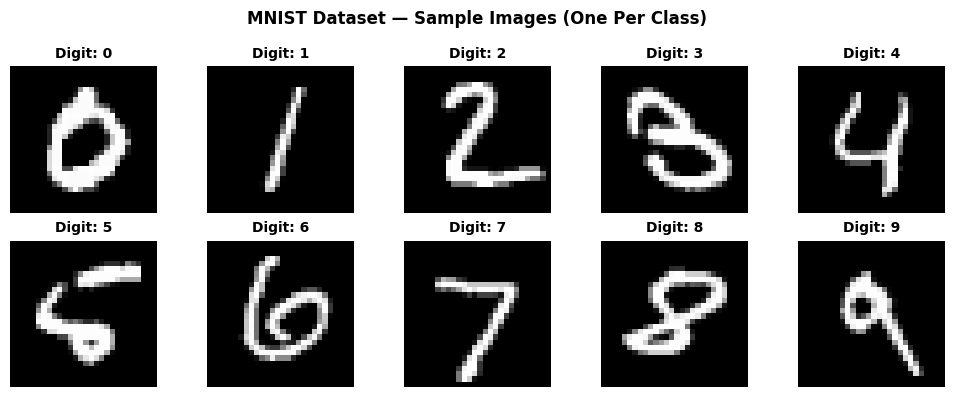

Figure 1 saved.


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
digit_shown = {}

for img, label in test_set:
    l = label  # already an int, no .item() needed
    if l not in digit_shown:
        digit_shown[l] = img.squeeze()
    if len(digit_shown) == 10:
        break

for i, (digit, img) in enumerate(sorted(digit_shown.items())):
    ax = axes[i//5, i%5]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Digit: {digit}', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('MNIST Dataset — Sample Images (One Per Class)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figure1_dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")